# RobustMesher: 2D Marmousi-II SEG-Y meshing

This example uses the attached raw Marmousi-II model, bundled as `RobustMesher/velocity_models/vp_marmousi-ii.segy`, and the original Spyro meshing functions. Run the cells in order: set the inputs, build the sizing function, generate and export the mesh, and plot it.

From the repository folder, install with `python -m pip install -e .` and open this notebook. The model is loaded as package data, so it is also available after a normal pip installation. Geometry coordinates and element sizes use **metres**; the attached SEG-Y stores velocity in **km/s**. This example multiplies the original sizing function's result by 1000 to express its wavelength-derived element sizes in metres. The raw SEG-Y and all original sizing, geometry, and adaptation algorithms remain unchanged.

The supplied model has **2801 depth samples and 13601 horizontal traces**, both spaced **1.25 m** apart, over **17000 m × 3500 m**. Its water marker is **1.5 km/s**, and its raw velocities range from approximately **1.028 to 4.7 km/s**. These model dimensions, spacings, and units match the [PySIT Marmousi-II model definition](https://github.com/pysit/pysit/blob/master/pysit/gallery/marmousi2.py). The SEG-Y sample interval is not used as a spatial grid spacing.

The configured example uses a **15 Hz** sizing frequency, **50 m** initial structured quadrilaterals, a delimited water interface, and **3000 Numba Winslow iterations** with relaxation 0.10 and no padding. Its retained output records **24,966 exported nodes** and **24,552 quadrilaterals**. The plotting preview alone is decimated; sizing and water-interface construction use the complete model.

The execution outputs and figures supplied with this notebook are retained from the user's run. This staged notebook was validated for format and Python syntax without repeating that calculation.

In [1]:
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from RobustMesher import generate_mesh, plot_mesh
from RobustMesher.Io_utils import read_segy_for_meshing
from RobustMesher.sizing_utils import create_sizing_function

## Inputs

Every configurable input is annotated on its right. Set the physical extent to match the supplied velocity model.

In [2]:
velocity_file = Path(str(files("RobustMesher").joinpath("velocity_models", "vp_marmousi-ii.segy")))  # Packaged raw Marmousi-II SEG-Y; velocities are km/s.
output_dir = Path("output")                               # Directory for exported mesh and figures.
mesh_file = output_dir / "marmousi_mesh_2D.msh"             # Gmsh mesh output, including physical groups.
figure_file = output_dir / "marmousi_mesh_2D.png"           # Mesh preview image output.

nz = 2801                      # Number of depth samples in the bundled Marmousi SEG-Y.
nx = 13601                     # Number of horizontal traces in the bundled Marmousi SEG-Y.
dz = 1.25                      # Depth spacing in metres.
dx = 1.25                      # Horizontal trace spacing in metres.
length_x = (nx - 1) * dx      # Physical model width: 17000 m.
length_z = (nz - 1) * dz      # Positive physical model depth: 3500 m.
frequency = 15.0               # Frequency in Hz used to convert velocity to wavelength.
cells_per_wavelength = 2.0    # Elements per wavelength in the velocity-derived sizing field.
hmin_segy = 0.0               # Minimum desired element size in metres; 0 keeps wavelength-derived values.
grade = 0.01                  # Local Savitzky-Golay smoothing fraction for this full-resolution large model.
vp_water = 1.5                # Raw km/s velocity substituted for zeros during original sizing.
velocity_unit_scale = 1000.0  # Convert the raw km/s velocity-derived size from km to metres.
preview_stride = 8            # Read full data; decimate only plotted arrays by this stride.

padding_type = None#"hyperelliptical"           # None, "rectangular", or "hyperelliptical" padding geometry.
padding_x = 1500.0             # Left and right padding thickness in metres; used when padding is enabled.
padding_z = 1500.0             # Bottom padding thickness in metres; the upper boundary stays free.
hyper_n = 4.0                 # Hyperellipse exponent; used only for hyperelliptical padding.
extend_segy = True            # Extend model-derived sizes into padding; False blends toward h_padding.
h_padding = 1000.0            # Outer padding element size in metres when extend_segy is False.
water_interface = True        # Split water/subsoil geometry using the velocity-model water interface.
water_search_value = 1.5      # Raw SEG-Y velocity marking water, in km/s; geometry reads this raw value.

structured_mesh = True        # True creates structured quadrilaterals using min_element_size.
unstructured_quad_mesh = False # True creates unstructured quadrilaterals; requires structured_mesh=False.
min_element_size = 50.0      # Initial structured-mesh element size in metres; smaller creates more cells.
apply_winslow = True          # Apply the source Winslow adaptation to a structured mesh.
winslow_implementation = "numba" # "numba", "fast" (vectorized), or "default" 2D Winslow implementation.
winslow_iterations = 3000        # Configured Winslow iteration count.
winslow_omega = 0.10          # Winslow relaxation factor; smaller values move nodes more cautiously.

if not velocity_file.is_file():
    raise FileNotFoundError(f"Velocity model not found: {velocity_file.resolve()}")
output_dir.mkdir(parents=True, exist_ok=True)

## Create the sizing function

This explicitly constructs the sizing field before calling mesh generation. The original function sees the raw SEG-Y velocities in km/s, so its wavelength-derived sizes are in km. The example wraps its callable and converts its minimum and maximum sizes to metres; sample counts stay unchanged. Bounding boxes and padding dimensions are already in metres, and the requested minimum size is converted to km before calling the original function.

In [3]:
native_sizing_result = create_sizing_function(
    fname=str(velocity_file),
    hmin=hmin_segy / velocity_unit_scale,
    bbox=(-length_z, 0.0, 0.0, length_x),
    wl=cells_per_wavelength,
    freq=frequency,
    pad_type=padding_type,
    pad_size_x=padding_x,
    pad_size_z=padding_z,
    grade=grade,
    vp_water=vp_water,
)
native_sizing_function, native_hmin, native_hmax, nz_read, nx_read = native_sizing_result
if (nz_read, nx_read) != (nz, nx):
    raise ValueError(f"SEG-Y shape {(nz_read, nx_read)} does not match input shape {(nz, nx)}.")


def sizing_function(x, z):
    return velocity_unit_scale * native_sizing_function(x, z)


hmin = velocity_unit_scale * native_hmin
hmax = velocity_unit_scale * native_hmax
sizing_result = (sizing_function, hmin, hmax, nz_read, nx_read)
print(f"Model: {nx} traces, {nz} depth samples; physical extent = {length_x:g} × {length_z:g} m")
print(f"Sizing units converted by ×{velocity_unit_scale:g}; h = {hmin:.2f} to {hmax:.2f} m")

Reading SEGY file: /home/juninhoras/firedrakes/spyro/RobustMesher/velocity_models/vp_marmousi-ii.segy
Final velocity range: 1.0 - 4.7
2801
13601
Function Minimum and Maximum values:
0.030477909598892225 0.1609272433088517
Model: 13601 traces, 2801 depth samples; physical extent = 17000 × 3500 m
Sizing units converted by ×1000; h = 30.48 to 160.93 m


Reading SEGY file: /home/juninhoras/firedrakes/spyro/RobustMesher/velocity_models/vp_marmousi-ii.segy
Final velocity range: 1.0 - 4.7
Full raw velocity range: 1.0280 to 4.7000 km/s
Water marker supplied to original geometry: 1.5 km/s


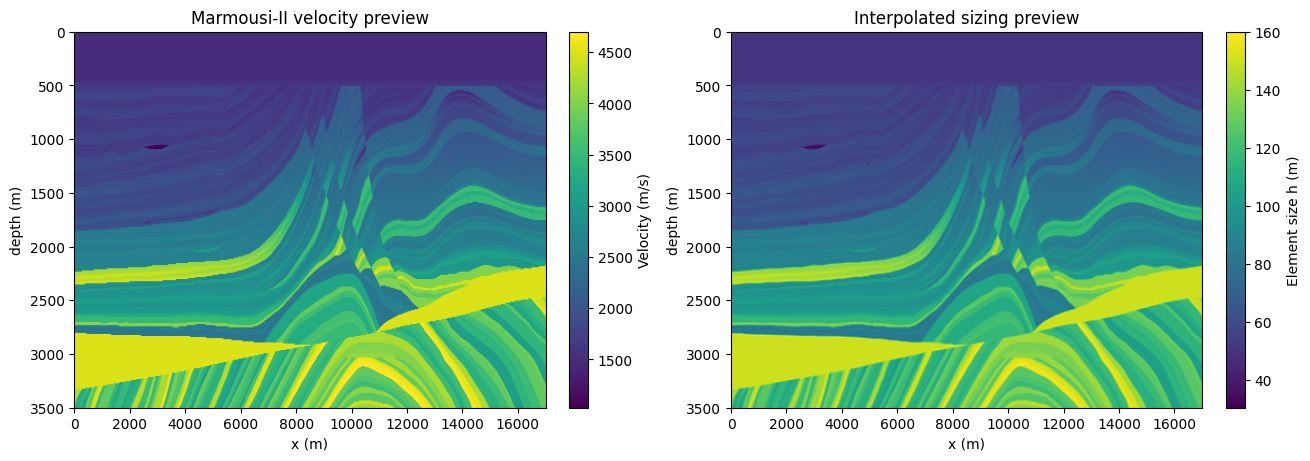

Only the preview is decimated: (351, 1701); meshing uses the full (2801, 13601) model.


In [4]:
velocity_raw, _, _ = read_segy_for_meshing(str(velocity_file))
print(f"Full raw velocity range: {velocity_raw.min():.4f} to {velocity_raw.max():.4f} km/s")
print(f"Water marker supplied to original geometry: {water_search_value:g} km/s")
velocity_preview = velocity_unit_scale * velocity_raw[::preview_stride, ::preview_stride]
del velocity_raw
x_plot = np.arange(0, nx, preview_stride) * dx
depth_plot = np.arange(0, nz, preview_stride) * dz
xx, dd = np.meshgrid(x_plot, depth_plot)
size_plot = sizing_function(xx, -dd)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, values, title, label in zip(
    axes, [velocity_preview, size_plot], ["Marmousi-II velocity preview", "Interpolated sizing preview"],
    ["Velocity (m/s)", "Element size h (m)"],
):
    image = ax.imshow(values, extent=(0, length_x, length_z, 0), aspect="auto")
    ax.set(xlabel="x (m)", ylabel="depth (m)", title=title)
    fig.colorbar(image, ax=ax, label=label)
plt.show()
print(f"Only the preview is decimated: {velocity_preview.shape}; meshing uses the full {(nz, nx)} model.")

## Generate and export the mesh

The generator receives the previously created sizing function and the geometry/adaptation parameters. It writes the Gmsh `.msh` file with the original physical groups and returns a mesh for plotting.

In [5]:
mesh = generate_mesh(
    sizing_function=sizing_result,
    dimension=2,
    velocity_file=str(velocity_file),
    length_x=length_x,
    length_z=length_z,
    padding_type=padding_type,
    padding_x=padding_x,
    padding_z=padding_z,
    hyper_n=hyper_n,
    extend_segy=extend_segy,
    h_padding=h_padding,
    water_interface=water_interface,
    water_search_value=water_search_value,
    vp_water=vp_water,
    structured_mesh=structured_mesh,
    unstructured_quad_mesh=unstructured_quad_mesh,
    min_element_size=min_element_size,
    apply_winslow=apply_winslow,
    winslow_implementation=winslow_implementation,
    winslow_iterations=winslow_iterations,
    winslow_omega=winslow_omega,
    output_filename=str(mesh_file),
)
print(f"Mesh exported: {mesh_file.resolve()}")
print(f"Nodes: {len(mesh.points):,}")
for block in mesh.cells:
    if block.type in {"triangle", "quad"}:
        print(f"{block.type}: {len(block.data):,}")

Generating Gmsh mesh...
Reading SEGY file: /home/juninhoras/firedrakes/spyro/RobustMesher/velocity_models/vp_marmousi-ii.segy
Detected parameters: nx=13601, nz=2801
Calculated spacing: dx=1.25 m, dz=1.25 m


/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _length_z value (3500.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _length_x value (17000.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _padding_x value (1500.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _padding_z value (1500.0) appears to be in meters, but the current unit is km. Please check for consistency.
  warn(
/home/juninhoras/firedrakes/spyro/RobustMesher/generation_utils/parameters.py:458: UserWarning: _h_padding value (1000.0) appears to be in meters, bu

Info    : Meshing 1D...                                                                                     
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (BSpline)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.000774653s, CPU 0.000992s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 60%] Meshing surface 2 (Transfinite)
Info    : Done meshing 2D (Wall 0.00255577s, CPU 0.002828s)
Info    : 38565 nodes 39324 elements
Aligning water columns with water spline X positions...
Snapped 3717 water-surface nodes onto 342 spline-X columns.
Nodes Breakdown | Total: 38565
Move All: 33999 | X-Slide: 340 | Z-Slide: 120 | hyperellipse: 0 | Locked: 4106
Applying Winslow smoothing...
Starting 3000 Winslow iterations...
Iteration: 3000 / 3000 [100.0%]   
S

## Plot the exported mesh

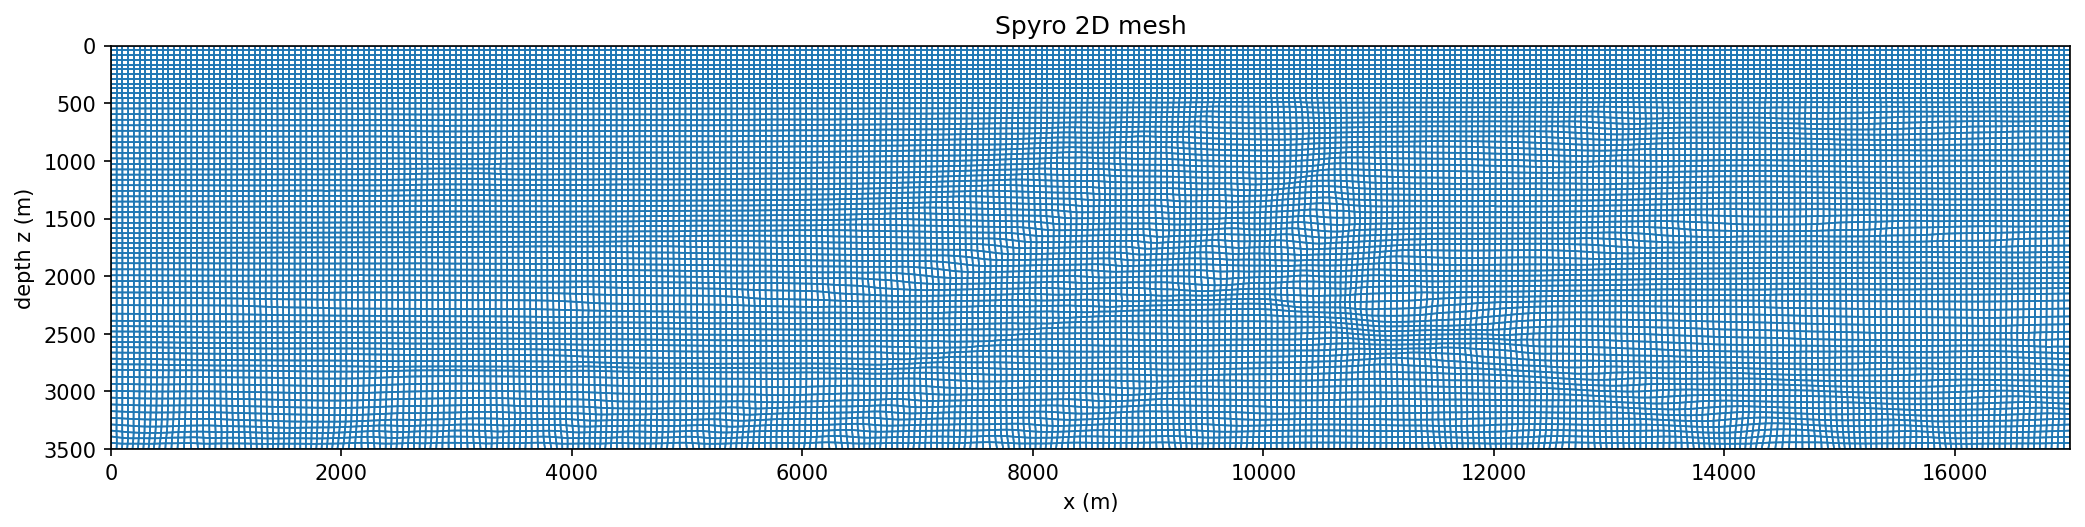

<Figure size 640x480 with 0 Axes>

Mesh preview saved: /home/juninhoras/firedrakes/spyro/output/marmousi_mesh_2D.png


In [6]:
plot_mesh(mesh, dimension=2)
plt.gcf().savefig(figure_file, dpi=180, bbox_inches="tight")
plt.show()
print(f"Mesh preview saved: {figure_file.resolve()}")